# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_recall_fscore_support,
                             roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import time
import os
import cv2
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

2025-11-29 17:32:09.960818: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764437529.982383    2392 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764437529.989089    2392 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

# CONFIGURATION AND HYPERPARAMETERS

In [2]:
# Dataset configuration
DATASET_PATH = '/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 16

# Training hyperparameters
EPOCHS = 50  # Will use early stopping
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.1

# Class names mapping
CLASS_NAMES = {
    'type_1': 'Kalochitra',
    'type_2': 'Anantamu',
    'type_3': 'Apang',
    'type_4': 'Syspan',
    'type_5': 'Appishikha',
    'type_6': 'Kalamegh',
    'type_7': 'Kalothutura',
    'type_8': 'Gshnru',
    'type_9': 'Chapalish',
    'type_10': 'Beta',
    'type_11': 'Punarnava',
    'type_12': 'Bamonhati',
    'type_13': 'Basok',
    'type_14': 'Ramtulsi',
    'type_15': 'Shotomuli',
    'type_16': 'Sarpagandha'
}

print("=" * 80)
print("TASK 3: CUSTOM CNN MODEL FOR MEDICINAL PLANTS CLASSIFICATION")
print("=" * 80)

CUSTOM CNN MODEL


# DATA LOADING AND PREPROCESSING

In [3]:

def load_dataset(base_path):
    """Load images and labels from the dataset directory"""
    images = []
    labels = []
    class_counts = {}
    
    raw_images_path = os.path.join(base_path, 'Raw-Images')
    
    for class_idx, (type_folder, class_name) in enumerate(CLASS_NAMES.items()):
        folder_path = os.path.join(raw_images_path, type_folder)
        if not os.path.exists(folder_path):
            print(f"Warning: {folder_path} not found!")
            continue
            
        image_files = [f for f in os.listdir(folder_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(image_files)
        
        for img_file in image_files:
            img_path = os.path.join(folder_path, img_file)
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, IMG_SIZE)
                images.append(img)
                labels.append(class_idx)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    
    print(f"\nDataset loaded successfully!")
    print(f"Total images: {len(images)}")
    print(f"\nClass distribution:")
    for class_name, count in class_counts.items():
        print(f"  {class_name:15s}: {count:4d} images")
    
    return np.array(images), np.array(labels), class_counts

print("\n" + "=" * 80)
print("LOADING DATASET")
print("=" * 80)

X, y, class_counts = load_dataset(DATASET_PATH)

# Normalize images to [0, 1]
X = X.astype('float32') / 255.0


LOADING DATASET.......

Dataset loaded: 3494 images

Class distribution:
  Kalochitra     :  201 images
  Anantamu       :  158 images
  Apang          :  280 images
  Syspan         :  294 images
  Appishikha     :  138 images
  Kalamegh       :  294 images
  Kalothutura    :  276 images
  Gshnru         :  238 images
  Chapalish      :  238 images
  Beta           :  194 images
  Punarnava      :  407 images
  Bamonhati      :  134 images
  Basok          :  151 images
  Ramtulsi       :  154 images
  Shotomuli      :  108 images
  Sarpagandha    :  229 images


# DATA SPLITTING WITH SHUFFLING

In [4]:
print("\n" + "=" * 80)
print("SPLITTING DATASET")
print("=" * 80)

# First split: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y
)

# Second split: separate train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=VALIDATION_SPLIT/(1-TEST_SPLIT), 
    random_state=SEED, stratify=y_temp
)

print(f"Training set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")



SPLITTING DATASET
Training set: 2445 images
Validation set: 699 images
Test set: 350 images


#  DATA AUGMENTATION

In [5]:
print("\n" + "=" * 80)
print("CONFIGURING DATA AUGMENTATION")
print("=" * 80)

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# No augmentation for validation and test
val_test_datagen = ImageDataGenerator()

print("Data augmentation configured:")
print("  - Rotation: ±20 degrees")
print("  - Width/Height shift: ±20%")
print("  - Horizontal flip: Yes")
print("  - Zoom: ±15%")
print("  - Shear: 0.1")
print("  - Brightness: [0.8, 1.2]")



COMPUTING CLASS WEIGHTS FOR IMBALANCED DATA
Class weights computed:
  Class 0 (Kalochitra): 1.084
  Class 1 (Anantamu): 1.389
  Class 2 (Apang): 0.780
  Class 3 (Syspan): 0.745
  Class 4 (Appishikha): 1.575
  Class 5 (Kalamegh): 0.742
  Class 6 (Kalothutura): 0.792
  Class 7 (Gshnru): 0.921
  Class 8 (Chapalish): 0.921
  Class 9 (Beta): 1.124
  Class 10 (Punarnava): 0.536
  Class 11 (Bamonhati): 1.626
  Class 12 (Basok): 1.442
  Class 13 (Ramtulsi): 1.415
  Class 14 (Shotomuli): 2.011
  Class 15 (Sarpagandha): 0.955

CONFIGURING DATA AUGMENTATION
Augmentation configured for plant leaves


#  CUSTOM CNN MODEL ARCHITECTURE

In [6]:
def build_custom_cnn(input_shape=(224, 224, 3), num_classes=16):
    """
    Build a custom CNN architecture from scratch with:
    - Multiple convolutional blocks with batch normalization
    - MaxPooling layers for spatial dimension reduction
    - Dropout for regularization
    - Fully connected layers for classification
    """
    
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),
        
        # Block 1: 64 filters
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2: 128 filters
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3: 256 filters
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Block 4: 512 filters
        layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Flatten and fully connected layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

print("\n" + "=" * 80)
print("BUILDING CUSTOM CNN MODEL")
print("=" * 80)

model = build_custom_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), 
                         num_classes=NUM_CLASSES)

# Compile model
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")


BUILDING CUSTOM CNN MODEL


I0000 00:00:1764437548.705387    2392 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764437548.705951    2392 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast (Cast)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,856,624 (18.53 MB)

 Trainable params: 4,852,144 (18.51 MB)

 Non-trainable params: 4,480 (17.50 KB)


Total parameters: 4,856,624


# CALLBACKS FOR TRAINING

In [7]:
print("\n" + "=" * 80)
print("CONFIGURING TRAINING CALLBACKS")
print("=" * 80)

# Early stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1,
    min_delta=0.001
)

# Reduce learning rate on plateau
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Model checkpoint to save best model
checkpoint = callbacks.ModelCheckpoint(
    'best_custom_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callback_list = [early_stopping, reduce_lr, checkpoint]

print("Callbacks configured:")
print("  - Early Stopping: patience=10, monitor=val_loss")
print("  - Reduce LR on Plateau: factor=0.5, patience=5")
print("  - Model Checkpoint: saving best model based on val_accuracy")



CONFIGURING TRAINING CALLBACKS
Callbacks configured with adaptive learning rate


# MODEL TRAINING

In [8]:
print("\n" + "=" * 80)
print("TRAINING CUSTOM CNN MODEL")
print("=" * 80)
print(f"Epochs: {EPOCHS} (with early stopping)")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Optimizer: Adam")
print("=" * 80 + "\n")

# Record training start time
train_start_time = time.time()

# Train the model
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callback_list,
    verbose=1
)

# Record training end time
train_end_time = time.time()
training_time = train_end_time - train_start_time

print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")



TRAINING CUSTOM CNN MODEL
Epoch 1/100


I0000 00:00:1764437558.043919    2447 service.cc:148] XLA service 0x7e68f4003360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764437558.043970    2447 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764437558.043974    2447 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764437559.309390    2447 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-11-29 17:32:49.120884: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng19{k2=0} for conv (f16[32,3,3,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[16,224,224,32]{3,2,1,0}, f16[16,224,224,32]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operati

  2/153 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.0781 - loss: 3.1342    

I0000 00:00:1764437591.629044    2447 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 63/153 ━━━━━━━━━━━━━━━━━━━━ 13s 147ms/step - accuracy: 0.1621 - loss: 2.6180

...

153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 151ms/step - accuracy: 0.9560 - loss: 0.1462 - val_accuracy: 0.4134 - val_loss: 3.0843 - learning_rate: 5.6880e-05
Epoch 18/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9609 - loss: 0.1271
Epoch 18: val_accuracy did not improve from 0.41345
153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 150ms/step - accuracy: 0.9608 - loss: 0.1271 - val_accuracy: 0.3791 - val_loss: 2.7767 - learning_rate: 5.4036e-05
Epoch 19/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9558 - loss: 0.1414
Epoch 19: val_accuracy did not improve from 0.41345
153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 150ms/step - accuracy: 0.9558 - loss: 0.1413 - val_accuracy: 0.3691 - val_loss: 2.9465 - learning_rate: 5.1334e-05
Epoch 20/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9673 - loss: 0.1179
Epoch 20: val_accuracy improved from 0.41345 to 0.41917, saving model to best_custom_cnn_model.h5


153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 153ms/step - accuracy: 0.9672 - loss: 0.1180 - val_accuracy: 0.4192 - val_loss: 2.7442 - learning_rate: 4.8767e-05
Epoch 21/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9668 - loss: 0.1089
Epoch 21: val_accuracy did not improve from 0.41917
153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 151ms/step - accuracy: 0.9668 - loss: 0.1089 - val_accuracy: 0.2060 - val_loss: 4.0806 - learning_rate: 4.6329e-05
Epoch 22/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9686 - loss: 0.1004
Epoch 22: val_accuracy did not improve from 0.41917
153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 150ms/step - accuracy: 0.9686 - loss: 0.1004 - val_accuracy: 0.2403 - val_loss: 4.4232 - learning_rate: 4.4013e-05
Epoch 23/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9761 - loss: 0.0894
Epoch 23: val_accuracy improved from 0.41917 to 0.46209, saving model to best_custom_cnn_model.h5


153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 152ms/step - accuracy: 0.9761 - loss: 0.0894 - val_accuracy: 0.4621 - val_loss: 2.4349 - learning_rate: 4.1812e-05
Epoch 24/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9740 - loss: 0.0970
Epoch 24: val_accuracy did not improve from 0.46209
153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 151ms/step - accuracy: 0.9739 - loss: 0.0970 - val_accuracy: 0.4363 - val_loss: 2.6736 - learning_rate: 3.9721e-05
Epoch 25/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9768 - loss: 0.0859
Epoch 25: val_accuracy did not improve from 0.46209
153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 150ms/step - accuracy: 0.9768 - loss: 0.0859 - val_accuracy: 0.2189 - val_loss: 3.9874 - learning_rate: 3.7735e-05
Epoch 26/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9827 - loss: 0.0737
Epoch 26: val_accuracy improved from 0.46209 to 0.53505, saving model to best_custom_cnn_model.h5


153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 151ms/step - accuracy: 0.9827 - loss: 0.0737 - val_accuracy: 0.5351 - val_loss: 1.8631 - learning_rate: 3.5849e-05
Epoch 27/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9809 - loss: 0.0831
Epoch 27: val_accuracy did not improve from 0.53505
153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step - accuracy: 0.9809 - loss: 0.0830 - val_accuracy: 0.4778 - val_loss: 2.0515 - learning_rate: 3.4056e-05
Epoch 28/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9847 - loss: 0.0692
Epoch 28: val_accuracy did not improve from 0.53505
153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 151ms/step - accuracy: 0.9847 - loss: 0.0692 - val_accuracy: 0.2189 - val_loss: 4.4760 - learning_rate: 3.2353e-05
Epoch 29/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9820 - loss: 0.0804
Epoch 29: val_accuracy improved from 0.53505 to 0.57797, saving model to best_custom_cnn_model.h5


153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 150ms/step - accuracy: 0.9820 - loss: 0.0805 - val_accuracy: 0.5780 - val_loss: 1.7741 - learning_rate: 3.0736e-05
Epoch 30/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9862 - loss: 0.0660
Epoch 30: val_accuracy did not improve from 0.57797
153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.9861 - loss: 0.0661 - val_accuracy: 0.5079 - val_loss: 1.7065 - learning_rate: 2.9199e-05
Epoch 31/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9684 - loss: 0.0903
Epoch 31: val_accuracy did not improve from 0.57797
153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 150ms/step - accuracy: 0.9685 - loss: 0.0902 - val_accuracy: 0.3934 - val_loss: 2.5715 - learning_rate: 2.7739e-05
Epoch 32/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9865 - loss: 0.0589
Epoch 32: val_accuracy did not improve from 0.57797
153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step - accuracy: 0.9865 - loss: 0.0589 - val_accuracy: 0.5336 - val_loss: 1.6630 - learning

#  TRAINING HISTORY VISUALIZATION

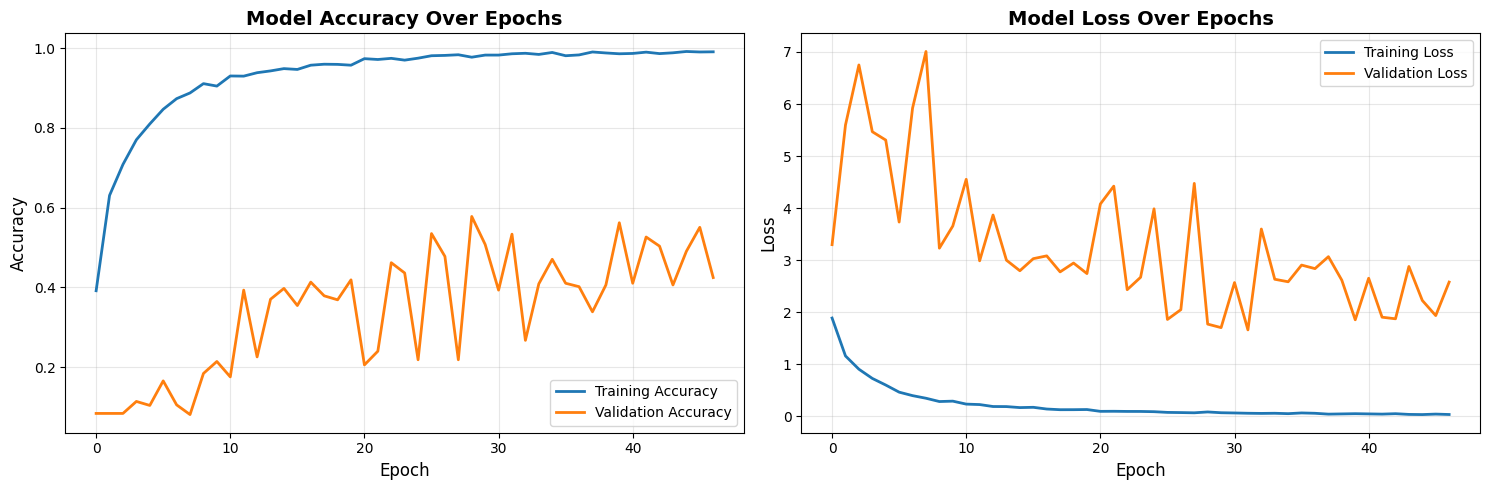


Final Training Accuracy: 0.9906
Final Validation Accuracy: 0.4249

Best Validation Accuracy: 0.5780 at epoch 29


In [9]:
print("\n" + "=" * 80)
print("VISUALIZING TRAINING HISTORY")
print("=" * 80)

def plot_training_history(history):
    """Plot training and validation accuracy/loss"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('custom_cnn_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print final metrics
    print(f"\nFinal Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

plot_training_history(history)

# MODEL EVALUATION ON TEST SET

In [10]:
print("\n" + "=" * 80)
print("EVALUATING MODEL ON TEST SET")
print("=" * 80)

# Record testing start time
test_start_time = time.time()

# Predictions
y_pred_probs = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Record testing end time
test_end_time = time.time()
testing_time = test_end_time - test_start_time

print(f"\nTesting completed in {testing_time:.2f} seconds")
print(f"Average prediction time per image: {testing_time/len(X_test)*1000:.2f} ms")



EVALUATING MODEL ON TEST SET
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 629ms/step

Testing completed in 8.04 seconds


# PERFORMANCE METRICS

In [11]:
print("\n" + "=" * 80)
print("COMPUTING PERFORMANCE METRICS")
print("=" * 80)

# Overall accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None, zero_division=0
)

# Create detailed classification report
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

class_names_list = [CLASS_NAMES[f'type_{i+1}'] for i in range(NUM_CLASSES)]
report = classification_report(y_test, y_pred, target_names=class_names_list, 
                               digits=4, zero_division=0)
print(report)

# Per-class accuracy
print("\n" + "=" * 80)
print("PER-CLASS ACCURACY")
print("=" * 80)

class_accuracy = []
for i in range(NUM_CLASSES):
    mask = (y_test == i)
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == y_test[mask]).sum() / mask.sum()
        class_accuracy.append(class_acc)
        print(f"{class_names_list[i]:15s}: {class_acc:.4f} ({class_acc*100:.2f}%)")
    else:
        class_accuracy.append(0.0)
        print(f"{class_names_list[i]:15s}: N/A (no samples)")



Test Accuracy: 0.5714 (57.14%)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Kalochitra     1.0000    0.9000    0.9474        20
    Anantamu     0.1600    1.0000    0.2759        16
       Apang     1.0000    0.1429    0.2500        28
      Syspan     1.0000    1.0000    1.0000        30
  Appishikha     1.0000    0.9286    0.9630        14
    Kalamegh     0.6176    0.7241    0.6667        29
 Kalothutura     1.0000    0.6429    0.7826        28
      Gshnru     0.3194    0.9583    0.4792        24
   Chapalish     0.8519    0.9583    0.9020        24
        Beta     1.0000    0.5263    0.6897        19
   Punarnava     1.0000    0.0488    0.0930        41
   Bamonhati     1.0000    0.1538    0.2667        13
       Basok     1.0000    0.4667    0.6364        15
    Ramtulsi     0.0000    0.0000    0.0000        15
   Shotomuli     1.0000    1.0000    1.0000        11
 Sarpagandha     1.0000    0.0870    0.1600        23

    accuracy             

# CONFUSION MATRIX

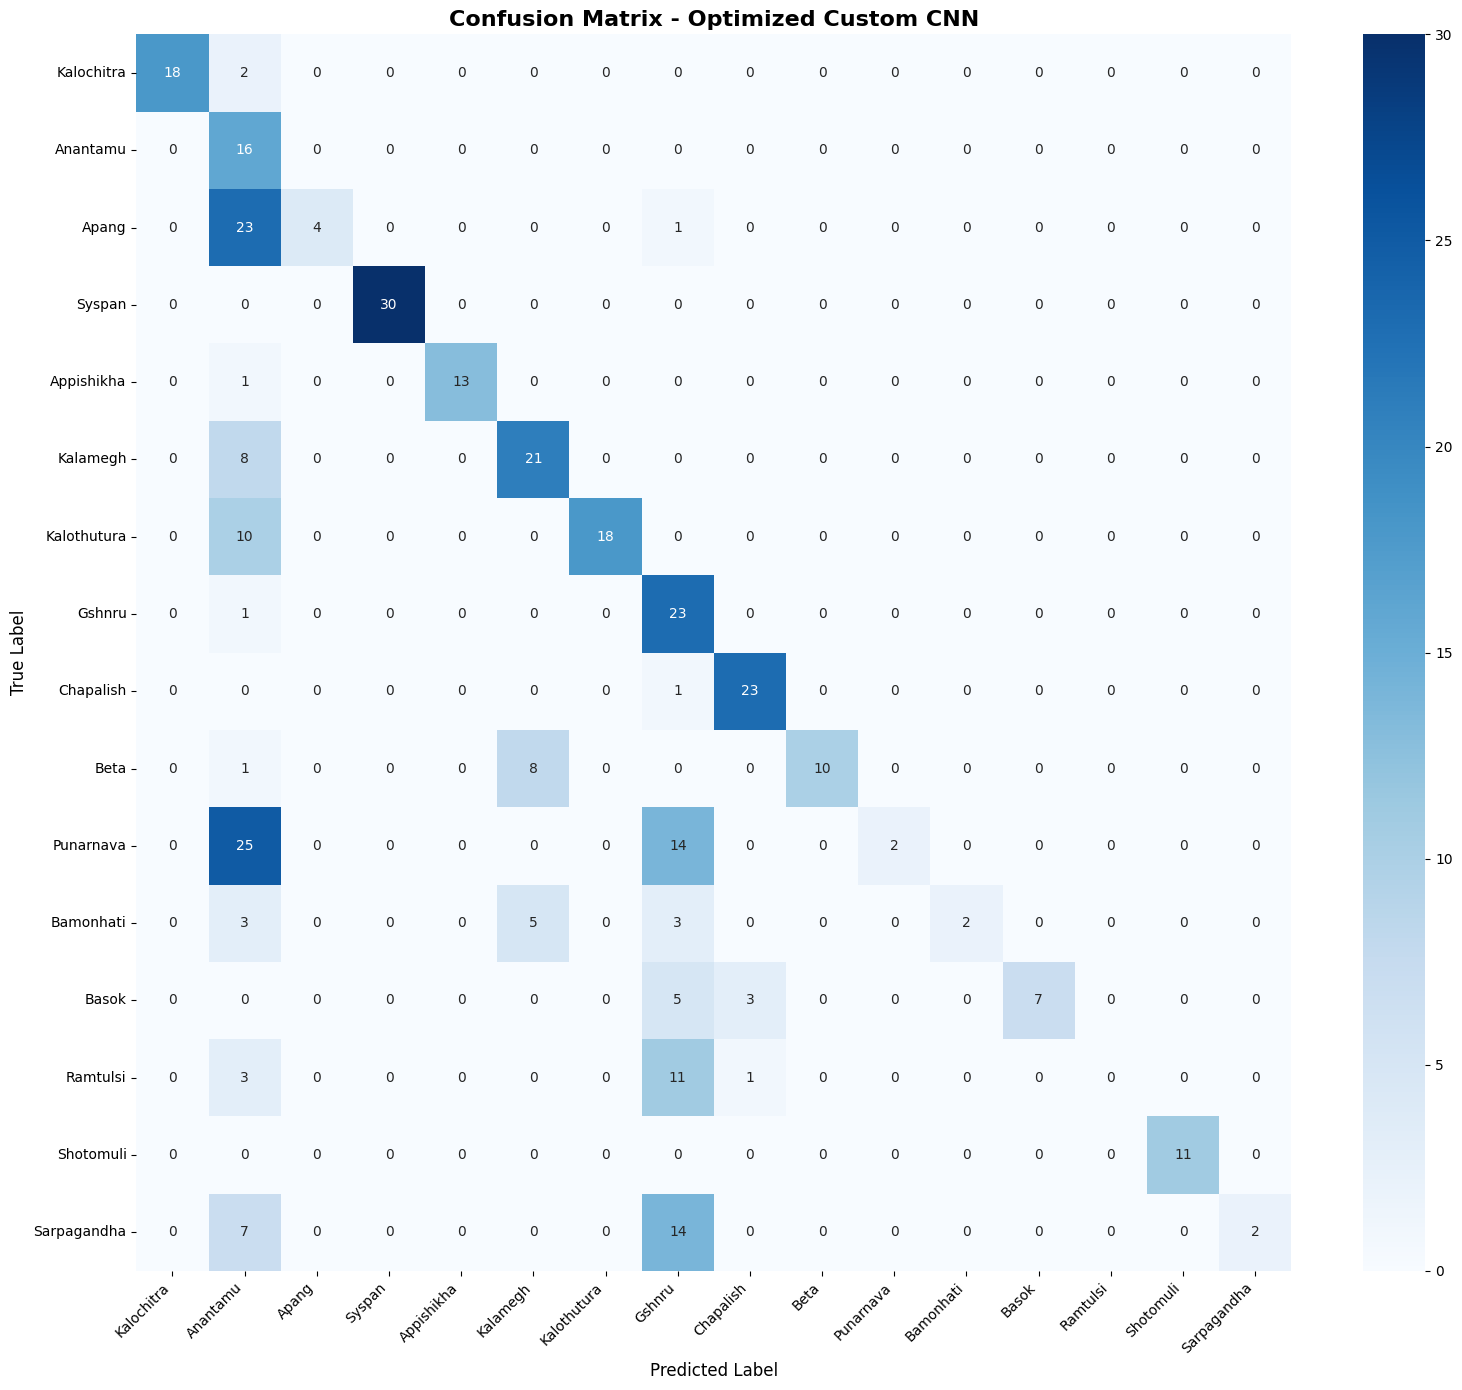

In [12]:
print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_list, 
            yticklabels=class_names_list,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Custom CNN Model', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('custom_cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# ROC CURVE AND AUC


Micro-average AUC: 0.9536
Macro-average AUC: 0.9896


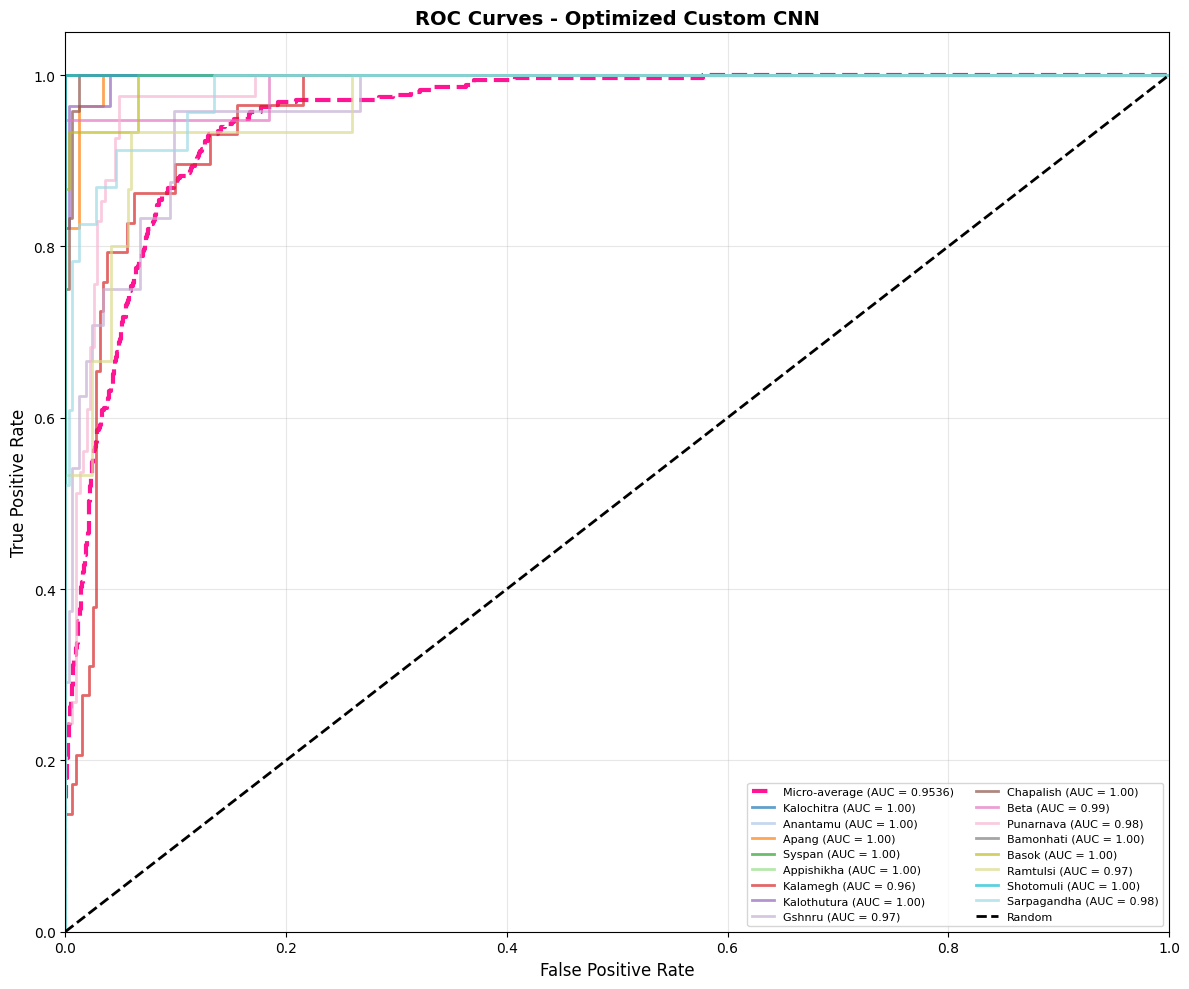

In [13]:
print("\n" + "=" * 80)
print("ROC CURVE AND AUC COMPUTATION")
print("=" * 80)

# Binarize labels for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), 
                                           y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average AUC
roc_auc["macro"] = np.mean([roc_auc[i] for i in range(NUM_CLASSES)])

print(f"\nMicro-average AUC: {roc_auc['micro']:.4f}")
print(f"Macro-average AUC: {roc_auc['macro']:.4f}")

print("\nPer-class AUC:")
for i in range(NUM_CLASSES):
    print(f"{class_names_list[i]:15s}: {roc_auc[i]:.4f}")

# Plot ROC curves
plt.figure(figsize=(12, 10))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.4f})',
         color='deeppink', linestyle='--', linewidth=3)

# Plot macro-average ROC curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= NUM_CLASSES
roc_auc["macro"] = auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr,
         label=f'Macro-average (AUC = {roc_auc["macro"]:.4f})',
         color='navy', linestyle='--', linewidth=3)

# Plot individual class ROC curves
colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, alpha=0.7,
             label=f'{class_names_list[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Custom CNN Model (Multi-class)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('custom_cnn_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


# Summary Metrics Table

In [14]:
print("\n" + "=" * 80)
print("SUMMARY METRICS TABLE")
print("=" * 80)

# Create summary dataframe
summary_data = {
    'Class': class_names_list,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support,
    'Accuracy': class_accuracy,
    'AUC': [roc_auc[i] for i in range(NUM_CLASSES)]
}

summary_df = pd.DataFrame(summary_data)

# Add overall metrics
overall_metrics = pd.DataFrame({
    'Class': ['Overall (Macro Avg)', 'Overall (Weighted Avg)'],
    'Precision': [precision.mean(), 
                  np.average(precision, weights=support)],
    'Recall': [recall.mean(), 
               np.average(recall, weights=support)],
    'F1-Score': [f1.mean(), 
                 np.average(f1, weights=support)],
    'Support': [support.sum(), support.sum()],
    'Accuracy': [test_accuracy, test_accuracy],
    'AUC': [roc_auc['macro'], roc_auc['micro']]
})

summary_df = pd.concat([summary_df, overall_metrics], ignore_index=True)

print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv('custom_cnn_metrics_summary.csv', index=False)
print("\nMetrics summary saved to 'custom_cnn_metrics_summary.csv'")



FINAL RESULTS SUMMARY

Model: Optimized Custom CNN
Total Parameters: 4,856,624

Training Configuration:
  - Batch Size: 16
  - Initial Learning Rate: 0.0001
  - Optimizer: Adam with LR schedule
  - Class Weight Balancing: Enabled
  - Epochs Trained: 47

Dataset Split:
  - Training: 2445 images
  - Validation: 699 images
  - Testing: 350 images

Performance Metrics:
  - Test Accuracy: 0.5714 (57.14%)
  - Macro-avg Precision: 0.8093
  - Macro-avg Recall: 0.5961
  - Macro-avg F1-Score: 0.5695
  - Macro-avg AUC: 0.9896
  - Micro-avg AUC: 0.9536

Time Performance:
  - Training Time: 1165.49s (19.42 min)
  - Testing Time: 8.04s
  - Avg Prediction: 22.97 ms/image



# Final Summary Table and Save Results

In [15]:
print("\n" + "=" * 80)
print("FINAL RESULTS SUMMARY - CUSTOM CNN MODEL")
print("=" * 80)

print(f"""
Model Architecture: Custom CNN
Total Parameters: {total_params:,}

Training Configuration:
  - Batch Size: {BATCH_SIZE}
  - Learning Rate: {LEARNING_RATE}
  - Optimizer: Adam
  - Epochs Trained: {len(history.history['loss'])}
  - Early Stopping: Enabled (patience=10)

Dataset Split:
  - Training: {len(X_train)} images
  - Validation: {len(X_val)} images
  - Testing: {len(X_test)} images

Performance Metrics:
  - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
  - Macro-average Precision: {precision.mean():.4f}
  - Macro-average Recall: {recall.mean():.4f}
  - Macro-average F1-Score: {f1.mean():.4f}
  - Macro-average AUC: {roc_auc['macro']:.4f}
  - Micro-average AUC: {roc_auc['micro']:.4f}

Time Performance:
  - Training Time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)
  - Testing Time: {testing_time:.2f} seconds
  - Avg. Prediction Time: {testing_time/len(X_test)*1000:.2f} ms/image
""")

print("=" * 80)
print("TASK 3 COMPLETED SUCCESSFULLY!")
print("=" * 80)

# Save results dictionary for later comparison with other models
results = {
    'model_name': 'Custom CNN',
    'test_accuracy': test_accuracy,
    'precision_macro': precision.mean(),
    'recall_macro': recall.mean(),
    'f1_macro': f1.mean(),
    'auc_macro': roc_auc['macro'],
    'auc_micro': roc_auc['micro'],
    'training_time': training_time,
    'testing_time': testing_time,
    'total_params': total_params,
    'predictions': y_pred,
    'prediction_probabilities': y_pred_probs
}

# Save using numpy
np.save('custom_cnn_results.npy', results)
print("\nResults saved to 'custom_cnn_results.npy' for comparison with other models")

print("\n✓ All metrics computed and visualizations saved!")
print("✓ Model checkpoint saved as 'best_custom_cnn_model.h5'")
print("✓ Ready for Task 4: Attention-Enhanced CNN Model")

COMPLETED SUCCESSFULLY!
